In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [27]:
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## LOADING SALES DATASET FOR ANALYSIS

In [4]:
# Load data
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/MSA_Phase2/Project3_Sales_Data.csv')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head(10))

Mounted at /content/drive
Shape: 185,950 rows x 11 columns


,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12
5,5,295670,AA Batteries (4-pack),1,3.84,2019-12-31 22:58:00,"200 Jefferson St, New York City, NY 10001",12,3.84,New York City,22
6,6,295671,USB-C Charging Cable,1,11.95,2019-12-16 15:10:00,"928 12th St, Portland, OR 97035",12,11.95,Portland,15
7,7,295672,USB-C Charging Cable,2,11.95,2019-12-13 09:29:00,"813 Hickory St, Dallas, TX 75001",12,23.90,Dallas,9
8,8,295673,Bose SoundSport Headphones,1,99.99,2019-12-15 23:26:00,"718 Wilson St, Dallas, TX 75001",12,99.99,Dallas,23
9,9,295674,AAA Batteries (4-pack),4,2.99,2019-12-28 11:51:00,"77 7th St, Dallas, TX 75001",12,11.96,Dallas,11


## DATASET UNDERSTANDING AND DATASET PREPROCESSING

In [5]:
# Checking data types and missing values
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nUnique values:")
print(f"Products  : {df['Product'].nunique()}")
print(f"Cities    : {df['City'].nunique()}")
print(f"Months    : {df['Month'].nunique()}")
print(f"Hours     : {df['Hour'].nunique()}")

print("\nProducts list:")
print(df['Product'].unique())

print("\nCities list:")
print(df['City'].unique())

Data types:
Unnamed: 0            int64
Order ID              int64
Product              object
Quantity Ordered      int64
Price Each          float64
Order Date           object
Purchase Address     object
Month                 int64
Sales               float64
City                 object
Hour                  int64
dtype: object

Missing values:
Unnamed: 0          0
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
Sales               0
City                0
Hour                0
dtype: int64

Unique values:
Products  : 19
Cities    : 9
Months    : 12
Hours     : 24

Products list:
['Macbook Pro Laptop' 'LG Washing Machine' 'USB-C Charging Cable'
 '27in FHD Monitor' 'AA Batteries (4-pack)' 'Bose SoundSport Headphones'
 'AAA Batteries (4-pack)' 'ThinkPad Laptop' 'Lightning Charging Cable'
 'Google Phone' 'Wired Headphones' 'Apple Airpods Headphones'
 'Vareebadd Phone' 'iPhone' '20

## DATA PRE-PROCESSING STEPS

In [6]:
# Dropping unnamed index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Fixing leading spaces in City column
df['City'] = df['City'].str.strip()

# Converting Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Verifying fixes
print("City values after stripping:")
print(df['City'].unique())
print(f"\nOrder Date dtype: {df['Order Date'].dtype}")
print(f"\nFinal shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head(5))

City values after stripping:
['New York City' 'San Francisco' 'Atlanta' 'Portland' 'Dallas'
 'Los Angeles' 'Boston' 'Austin' 'Seattle']

Order Date dtype: datetime64[ns]

Final shape: 185,950 rows x 10 columns


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


In [7]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")

# Check relationship between Price Each and Sales
print("\nPrice Each vs Sales sample:")
display(df[['Product', 'Quantity Ordered', 'Price Each', 'Sales']].head(10))

# Verify Sales = Quantity Ordered x Price Each
df['Sales_check'] = df['Quantity Ordered'] * df['Price Each']
mismatch = (df['Sales_check'] != df['Sales']).sum()
print(f"\nRows where Sales ≠ Quantity × Price: {mismatch:,}")

if mismatch == 0:
    print("Confirmed: Sales = Quantity Ordered × Price Each for all rows")
    print("Sales column is derived — not an independent feature")
else:
    print(f"Warning: {mismatch} rows have mismatched Sales values")

# Drop the check column
df.drop(columns=['Sales_check'], inplace=True)

# Check for duplicate Order IDs
duplicate_orders = df['Order ID'].duplicated().sum()
print(f"\nDuplicate Order IDs: {duplicate_orders:,}")
print("Note: Same Order ID can appear multiple times if multiple")
print("products were ordered in the same order")

Duplicate rows: 264

Price Each vs Sales sample:


,Product,Quantity Ordered,Price Each,Sales
0,Macbook Pro Laptop,1,1700.00,1700.00
1,LG Washing Machine,1,600.00,600.00
2,USB-C Charging Cable,1,11.95,11.95
3,27in FHD Monitor,1,149.99,149.99
4,USB-C Charging Cable,1,11.95,11.95
5,AA Batteries (4-pack),1,3.84,3.84
6,USB-C Charging Cable,1,11.95,11.95
7,USB-C Charging Cable,2,11.95,23.90
8,Bose SoundSport Headphones,1,99.99,99.99
9,AAA Batteries (4-pack),4,2.99,11.96



Rows where Sales ≠ Quantity × Price: 265

Duplicate Order IDs: 7,513
Note: Same Order ID can appear multiple times if multiple
products were ordered in the same order


In [8]:
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows before: {before:,}")
print(f"Rows after : {len(df):,}")
print(f"Removed    : {before - len(df):,} duplicate rows")

Rows before: 185,950
Rows after : 185,686
Removed    : 264 duplicate rows


### Outlier Detection

We check for outliers in the numerical columns:
- `Quantity Ordered` - number of units ordered
- `Price Each` - unit price of product
- `Sales` - total order revenue

Box plots and IQR method are used to identify outliers.

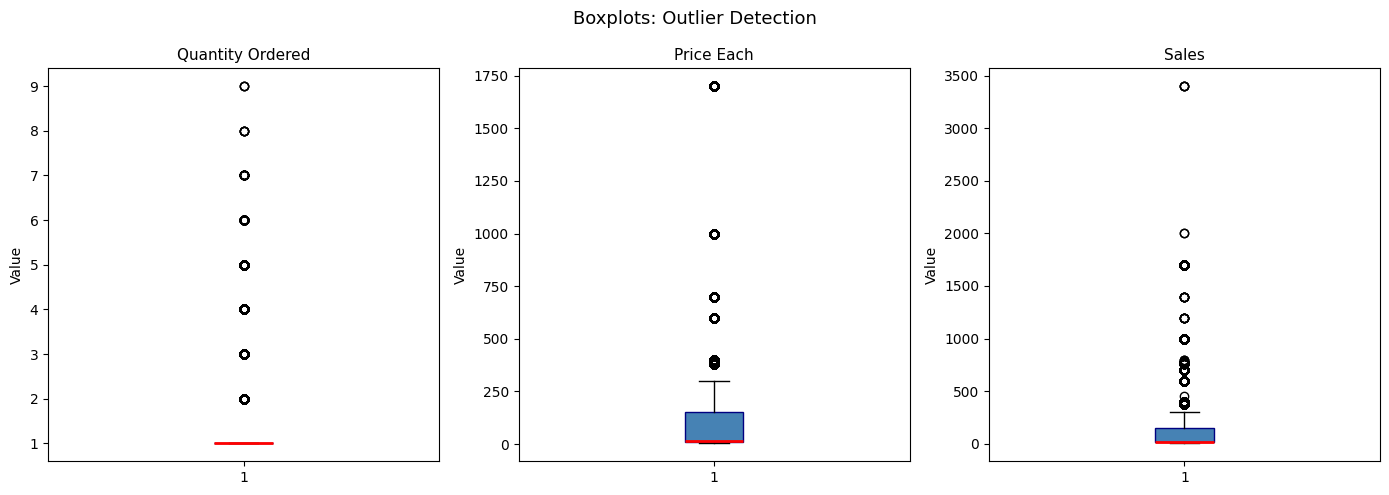

Outlier Detection using IQR method:
---------------------------------------------

  Quantity Ordered:
    Lower fence : 1.00
    Upper fence : 1.00
    Outliers    : 17,395

  Price Each:
    Lower fence : -195.13
    Upper fence : 357.08
    Outliers    : 36,985

  Sales:
    Lower fence : -195.13
    Upper fence : 357.08
    Outliers    : 37,005


In [9]:
# Checking outliers using boxplots
numerical_cols = ['Quantity Ordered', 'Price Each', 'Sales']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots: Outlier Detection', fontsize=13)
plt.tight_layout()
plt.show()

# IQR method
print("Outlier Detection using IQR method:")
print("-" * 45)
for col in numerical_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"\n  {col}:")
    print(f"    Lower fence : {lower:.2f}")
    print(f"    Upper fence : {upper:.2f}")
    print(f"    Outliers    : {outliers:,}")

### Outlier Detection

When I applied the IQR method to check for outliers, it flagged a large
number of values across all three numerical columns. However, looking
more closely at the data, these are not actually errors.

For **Quantity Ordered**, the IQR came out as 0 because the vast majority
of orders are for just 1 item. This means anything above 1 gets flagged,
but ordering 2, 3, or even 9 items in one transaction is completely normal
customer behaviour.

For **Price Each** and **Sales**, the lower fence came out negative, which
makes no sense for a price column. The high-value flagged entries turned out
to be premium products like the MacBook Pro ($1,700), these are real
products in the catalogue, not data errors.

Given this, all flagged values were retained. Removing them would mean
losing valid transactions and distorting the analysis.

In [10]:
# Finding mismatched rows
df['Sales_check'] = df['Quantity Ordered'] * df['Price Each']
mismatch = df[df['Sales_check'] != df['Sales']]

print(f"Mismatched rows: {len(mismatch):,}")
print("\nSample of mismatched rows:")
display(mismatch[['Product', 'Quantity Ordered',
                   'Price Each', 'Sales',
                   'Sales_check']].head(10))

print("\nDifference between Sales and calculated:")
diff = (mismatch['Sales'] - mismatch['Sales_check']).abs()
print(f"  Min difference : ${diff.min():.4f}")
print(f"  Max difference : ${diff.max():.4f}")
print(f"  Mean difference: ${diff.mean():.4f}")

df.drop(columns=['Sales_check'], inplace=True)

Mismatched rows: 265

Sample of mismatched rows:


,Product,Quantity Ordered,Price Each,Sales,Sales_check
834,AAA Batteries (4-pack),5,2.99,14.95,14.95
1100,AAA Batteries (4-pack),5,2.99,14.95,14.95
1754,Lightning Charging Cable,3,14.95,44.85,44.85
2674,AAA Batteries (4-pack),5,2.99,14.95,14.95
3134,Lightning Charging Cable,3,14.95,44.85,44.85
6437,Lightning Charging Cable,3,14.95,44.85,44.85
6830,AAA Batteries (4-pack),5,2.99,14.95,14.95
7525,AAA Batteries (4-pack),5,2.99,14.95,14.95
8375,Lightning Charging Cable,3,14.95,44.85,44.85
8444,AAA Batteries (4-pack),5,2.99,14.95,14.95



Difference between Sales and calculated:
  Min difference : $0.0000
  Max difference : $0.0000
  Mean difference: $0.0000


## EXPLORATORY DATA ANALYSIS (EDA)

### RESEARCH QUESTION 1:

Which month generates highest revenue?

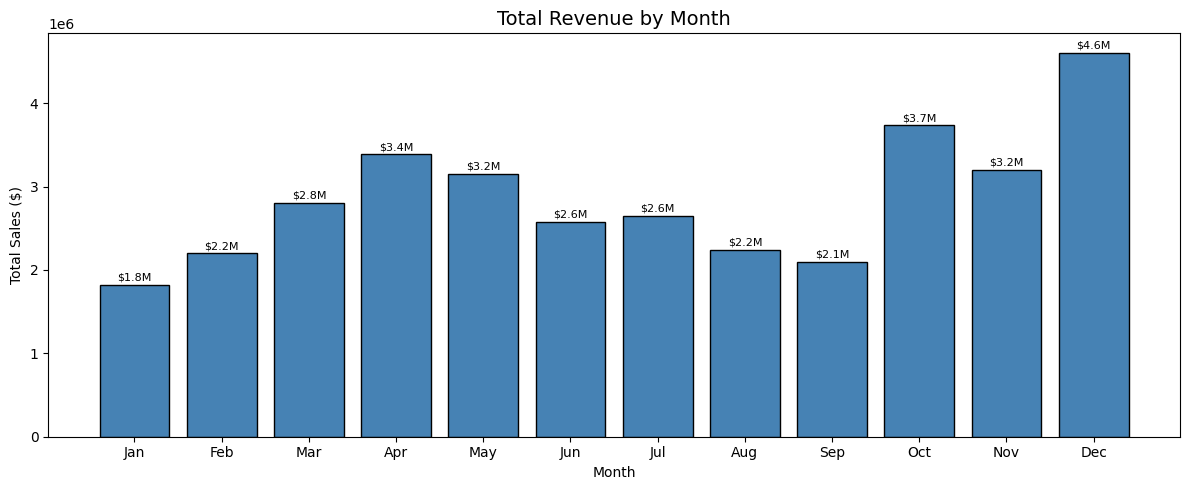

Highest revenue month: Dec ($4,608,295.70)


In [11]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month_Name'] = pd.to_datetime(monthly_sales['Month'], format='%m').dt.strftime('%b')

plt.figure(figsize=(12, 5))
bars = plt.bar(monthly_sales['Month_Name'], monthly_sales['Sales'],
               color='steelblue', edgecolor='black')
plt.title('Total Revenue by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
for bar, val in zip(bars, monthly_sales['Sales']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
             f'${val/1e6:.1f}M', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

peak_month = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
print(f"Highest revenue month: {peak_month['Month_Name']} (${peak_month['Sales']:,.2f})")

### RESEARCH QUESTION 2:

Which city contributes most sales?

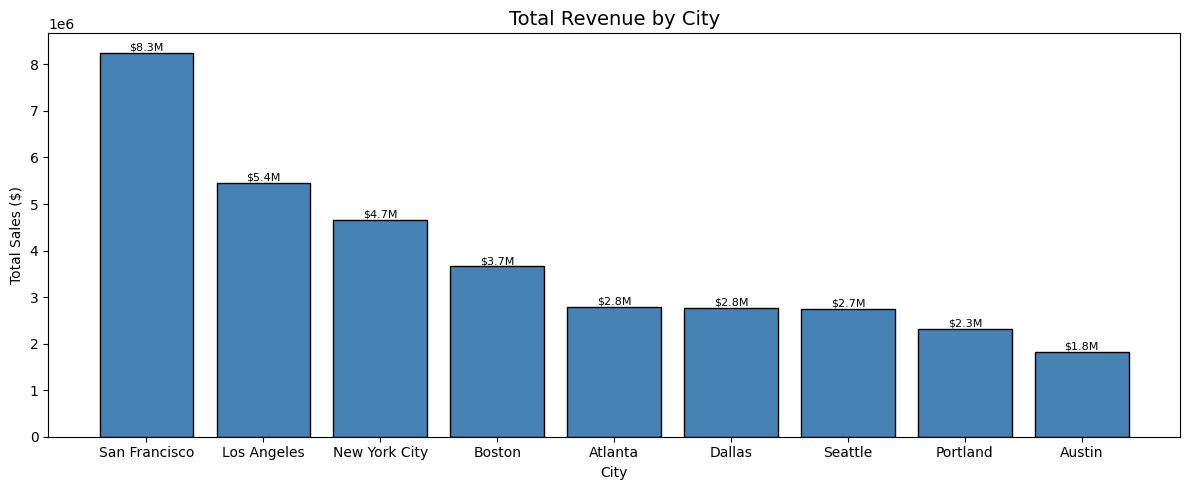

Revenue by city:
City
San Francisco    8254743.55
Los Angeles      5448304.28
New York City    4661867.14
Boston           3658627.65
Atlanta          2794199.07
Dallas           2765373.96
Seattle          2745046.02
Portland         2319331.94
Austin           1818044.33


In [12]:
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(city_sales.index, city_sales.values,
               color='steelblue', edgecolor='black')
plt.title('Total Revenue by City', fontsize=14)
plt.xlabel('City')
plt.ylabel('Total Sales ($)')
for bar, val in zip(bars, city_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
             f'${val/1e6:.1f}M', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("Revenue by city:")
print(city_sales.to_string())

### RESEARCH QUESTION 3:

Products with highest quantity and revenue

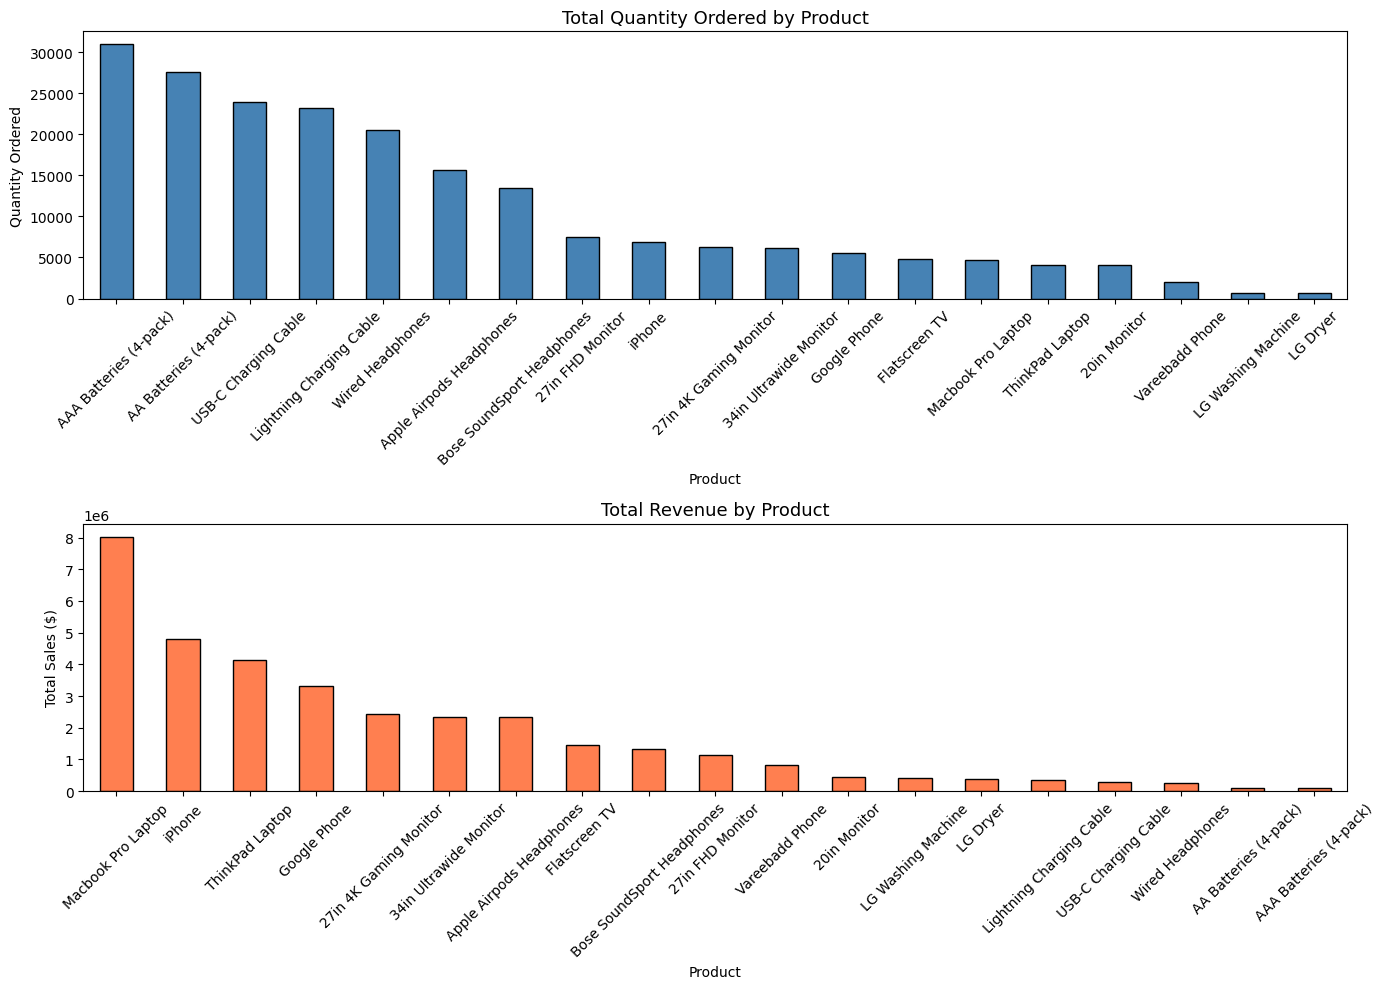

Top 5 by quantity:
Product
AAA Batteries (4-pack)      30986
AA Batteries (4-pack)       27615
USB-C Charging Cable        23931
Lightning Charging Cable    23169
Wired Headphones            20524
Name: Quantity Ordered, dtype: int64

Top 5 by revenue:
Product
Macbook Pro Laptop        8032500.00
iPhone                    4792900.00
ThinkPad Laptop           4127958.72
Google Phone              3317400.00
27in 4K Gaming Monitor    2433147.61
Name: Sales, dtype: float64


In [13]:
product_qty = df.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)
product_rev = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

product_qty.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Quantity Ordered by Product', fontsize=13)
axes[0].set_ylabel('Quantity Ordered')
axes[0].tick_params(axis='x', rotation=45)

product_rev.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Total Revenue by Product', fontsize=13)
axes[1].set_ylabel('Total Sales ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Top 5 by quantity:")
print(product_qty.head())
print("\nTop 5 by revenue:")
print(product_rev.head())

### RESEARCH QUESTION 4:
What time of day has the highest order activity?


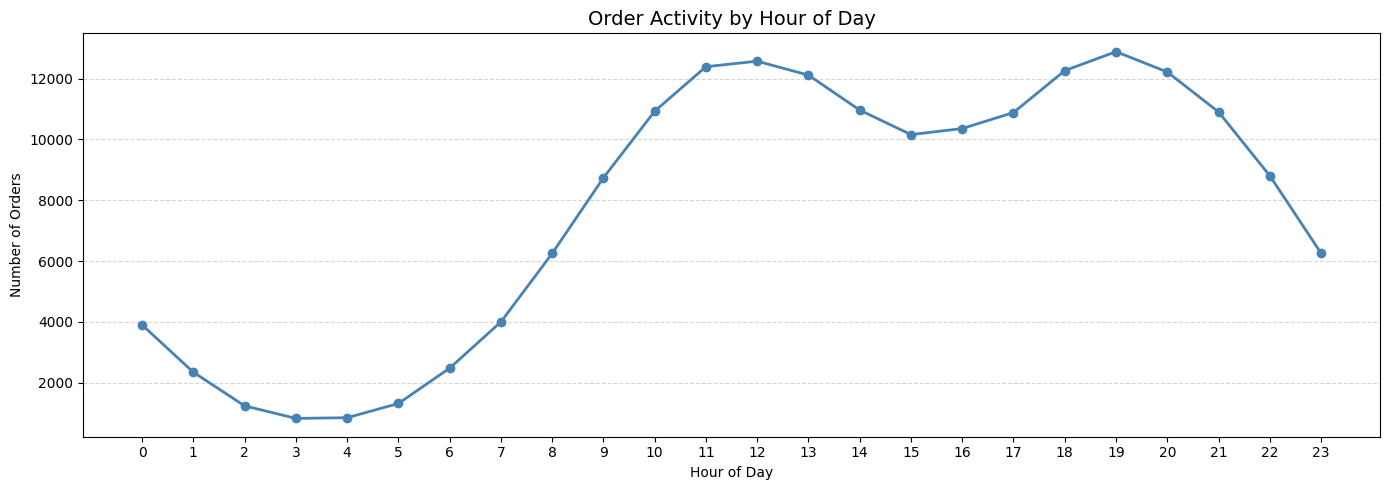

Peak order hour: 19:00 with 12,886 orders


In [14]:
hourly_orders = df.groupby('Hour')['Order ID'].count()

plt.figure(figsize=(14, 5))
plt.plot(hourly_orders.index, hourly_orders.values,
         color='steelblue', marker='o', linewidth=2)
plt.title('Order Activity by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

peak_hour = hourly_orders.idxmax()
print(f"Peak order hour: {peak_hour}:00 with {hourly_orders.max():,} orders")

## STATISTICAL ANALYSIS

### RESEARCH QUESTION 5:

Are expensive products sold less frequently?

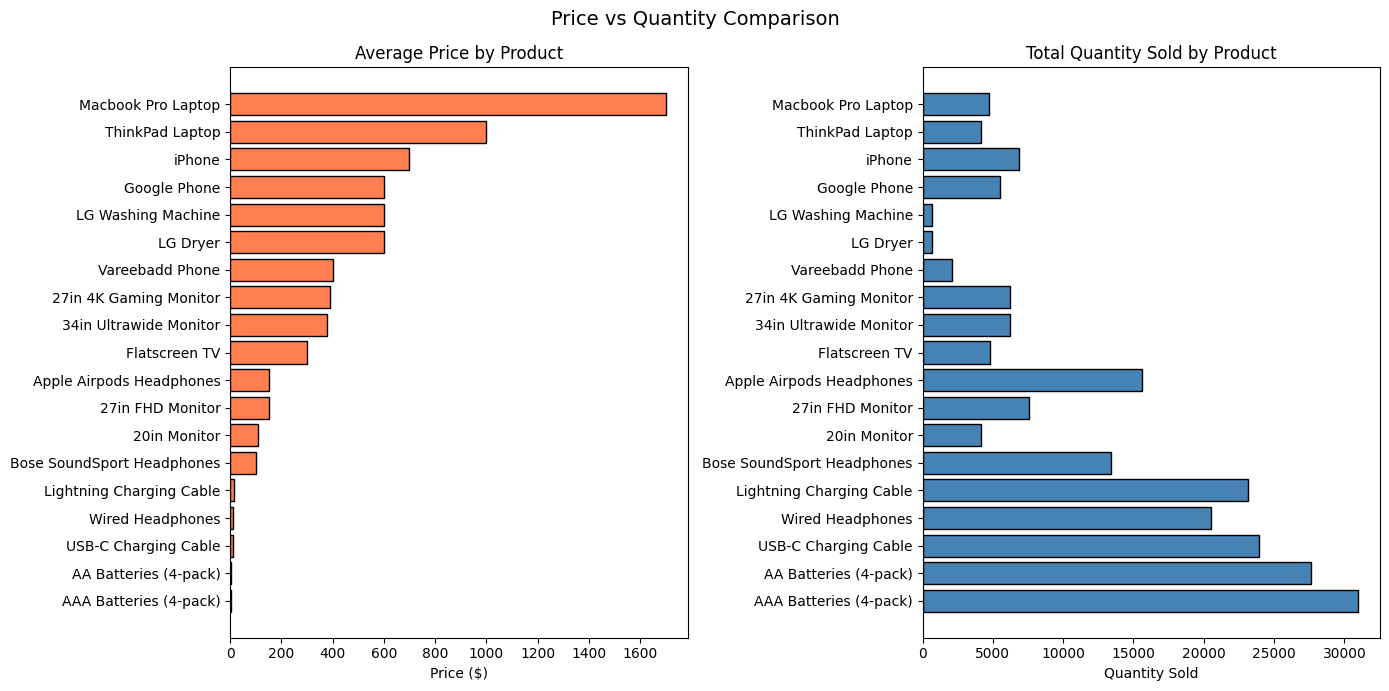

In [15]:
product_stats = df.groupby('Product').agg(
    Avg_Price=('Price Each', 'mean'),
    Total_Qty=('Quantity Ordered', 'sum'),
    Total_Revenue=('Sales', 'sum')
).reset_index()

product_stats_sorted = product_stats.sort_values('Avg_Price', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(product_stats_sorted['Product'],
             product_stats_sorted['Avg_Price'],
             color='coral', edgecolor='black')
axes[0].set_title('Average Price by Product', fontsize=12)
axes[0].set_xlabel('Price ($)')

axes[1].barh(product_stats_sorted['Product'],
             product_stats_sorted['Total_Qty'],
             color='steelblue', edgecolor='black')
axes[1].set_title('Total Quantity Sold by Product', fontsize=12)
axes[1].set_xlabel('Quantity Sold')

plt.suptitle('Price vs Quantity Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## MARKET BASKET ANALYSIS / ASSOCIATION RULES

### RESEARCH QUESTION 6:

Which products are frequently purchased together?


In [28]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Groupin by Order IDg
basket = df.groupby('Order ID')['Product'].apply(list).reset_index()

# Checking how many orders have more than 1 product
multi_item = basket['Product'].apply(len)
print(f"Orders with 1 product  : {(multi_item == 1).sum():,}")
print(f"Orders with 2+ products: {(multi_item >= 2).sum():,}")

# Only keeping orders with 2+ products
basket_multi = basket[multi_item >= 2]
transactions = basket_multi['Product'].tolist()
print(f"\nTransactions for basket analysis: {len(transactions):,}")

# Encoding
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

frequent_items = apriori(basket_df, min_support=0.001, use_colnames=True)
print(f"Frequent itemsets: {len(frequent_items)}")

# Lower lift threshold
rules = association_rules(frequent_items,
                          metric='confidence',
                          min_threshold=0.1)
rules = rules.sort_values('lift', ascending=False)

print(f"Association rules found: {len(rules)}")
print("\nTop 10 rules by lift:")
display(rules[['antecedents', 'consequents',
               'support', 'confidence', 'lift']].head(10))

Orders with 1 product  : 171,558
Orders with 2+ products: 6,879

Transactions for basket analysis: 6,879
Frequent itemsets: 130
Association rules found: 73

Top 10 rules by lift:


,antecedents,consequents,support,confidence,lift
46,(iPhone),(Lightning Charging Cable),0.146969,0.542382,2.159170
47,(Lightning Charging Cable),(iPhone),0.146969,0.585069,2.159170
52,(Vareebadd Phone),(USB-C Charging Cable),0.053496,0.612313,2.084166
51,(USB-C Charging Cable),(Vareebadd Phone),0.053496,0.182088,2.084166
40,(USB-C Charging Cable),(Google Phone),0.144934,0.493320,2.078107
41,(Google Phone),(USB-C Charging Cable),0.144934,0.610533,2.078107
71,"(USB-C Charging Cable, Wired Headphones)",(Vareebadd Phone),0.004797,0.162562,1.860667
67,"(USB-C Charging Cable, Wired Headphones)",(Google Phone),0.012647,0.428571,1.805354
69,"(Wired Headphones, Lightning Charging Cable)",(iPhone),0.009158,0.488372,1.802313
65,"(USB-C Charging Cable, Bose SoundSport Headpho...",(Vareebadd Phone),0.002326,0.156863,1.795439


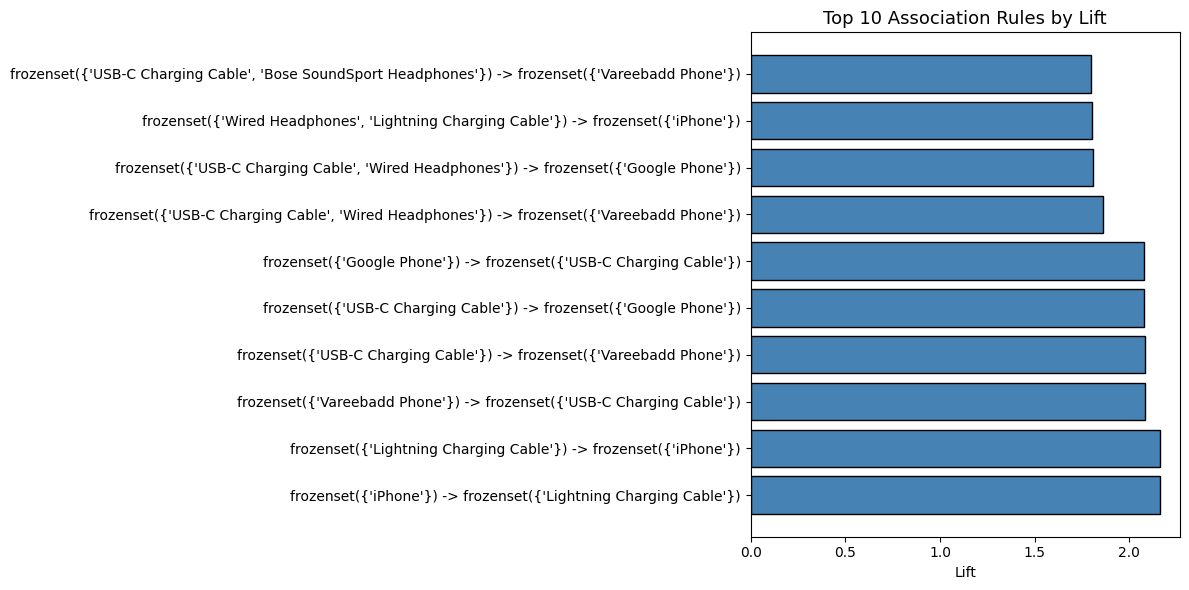

In [29]:
# Visualise top 10 rules
top_rules = rules.head(10).copy()
top_rules['rule'] = (top_rules['antecedents'].astype(str) +
                     ' -> ' +
                     top_rules['consequents'].astype(str))

plt.figure(figsize=(12, 6))
plt.barh(top_rules['rule'], top_rules['lift'],
         color='steelblue', edgecolor='black')
plt.xlabel('Lift')
plt.title('Top 10 Association Rules by Lift', fontsize=13)
plt.tight_layout()
plt.show()

## MACHINE LEARNING MODELLING

### RESEARCH QUESTION 7:

Can machine learning models predict sales revenue accurately?


## CORRELATION **MATRIX**

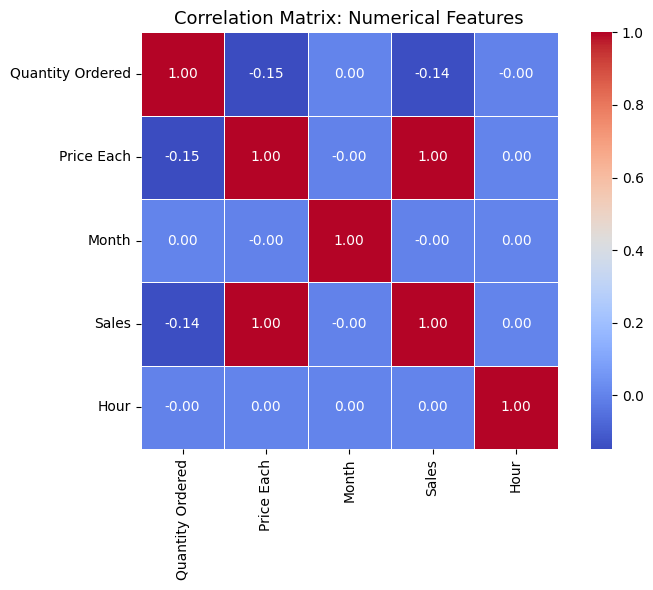

Correlation with Sales:
Sales               1.000
Price Each          0.999
Hour                0.002
Month              -0.003
Quantity Ordered   -0.140


In [30]:
# Correlation matrix of numerical features
numerical_cols = ['Quantity Ordered', 'Price Each', 'Month', 'Sales', 'Hour']

corr = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, annot_kws={"size": 10})
plt.title('Correlation Matrix: Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

print("Correlation with Sales:")
print(corr['Sales'].sort_values(ascending=False).round(3).to_string())

In [31]:
from scipy.stats import chi2_contingency

# Bin Sales for categorical comparison
df['Sales_bin'] = pd.cut(df['Sales'], bins=5,
                          labels=['Very Low', 'Low',
                                  'Medium', 'High',
                                  'Very High'])

# Chi-Square test — Product vs Sales
contingency_product = pd.crosstab(df['Product'],
                                   df['Sales_bin'])
chi2_product, p_product, dof_product, _ = chi2_contingency(
                                           contingency_product)

# Chi-Square test — City vs Sales
contingency_city = pd.crosstab(df['City'],
                                df['Sales_bin'])
chi2_city, p_city, dof_city, _ = chi2_contingency(
                                   contingency_city)

print("Chi-Square Test Results:")
print("-" * 45)
print(f"\nProduct vs Sales:")
print(f"  Chi-Square : {chi2_product:.2f}")
print(f"  P-value    : {p_product:.6f}")
print(f"  DOF        : {dof_product}")

print(f"\nCity vs Sales:")
print(f"  Chi-Square : {chi2_city:.2f}")
print(f"  P-value    : {p_city:.6f}")
print(f"  DOF        : {dof_city}")

print("\nInterpretation:")
for name, p in [('Product vs Sales', p_product),
                ('City vs Sales', p_city)]:
    if p < 0.05:
        print(f"  {name} - p < 0.05 significant association")
    else:
        print(f"  {name} - p > 0.05 no significant association")

# Clean up
df.drop(columns=['Sales_bin'], inplace=True)

Chi-Square Test Results:
---------------------------------------------

Product vs Sales:
  Chi-Square : 370114.02
  P-value    : 0.000000
  DOF        : 54

City vs Sales:
  Chi-Square : 11.01
  P-value    : 0.988913
  DOF        : 24

Interpretation:
  Product vs Sales - p < 0.05 significant association
  City vs Sales - p > 0.05 no significant association


## 7. Machine Learning Modelling

Two models are trained and compared to predict Sales revenue:
- **Random Forest Regressor** >> handles non-linear relationships well
- **Linear Regression** >> used as a baseline for comparison

### Feature Selection
The following features are selected:
- `Product_encoded`:product identity drives price and sales
- `Month`: captures seasonal sales patterns
- `Hour`: captures time-of-day purchasing behaviour
- `City_encoded`: captures geographic demand differences

### Excluded Features
- `Price Each`: data leakage (directly determines Sales)
- `Quantity Ordered`: data leakage (Sales = Price × Quantity)
- `Purchase Address`:redundant with City
- `Order Date`:already decomposed into Month and Hour

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Encoding categorical columns
le_product = LabelEncoder()
le_city    = LabelEncoder()
df['Product_encoded'] = le_product.fit_transform(df['Product'])
df['City_encoded']    = le_city.fit_transform(df['City'])

# Features and target
features = ['Product_encoded', 'Month', 'Hour', 'City_encoded']
target   = 'Sales'

X = df[features]
y = df[target]

print("Selected features:")
for f in features:
    print(f"  {f}")
print(f"\nTarget   : {target}")
print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")

Selected features:
  Product_encoded
  Month
  Hour
  City_encoded

Target   : Sales
X shape  : (185686, 4)
y shape  : (185686,)


### Data Split
The dataset is split into:
- **Training set (70%)** >> used to fit the model
- **Test set (30%)** >> used to evaluate performance on unseen data

A random state of 42 is set for reproducibility.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print(f"Total rows   : {len(X):,}")
print(f"Training set : {X_train.shape[0]:,} rows (70%)")
print(f"Test set     : {X_test.shape[0]:,} rows (30%)")

Total rows   : 185,686
Training set : 129,980 rows (70%)
Test set     : 55,706 rows (30%)


### Model Training

Two models are trained and compared:

**Random Forest Regressor:**
- An ensemble method that builds multiple decision trees and averages
  their predictions
- Handles non-linear relationships well
- Robust to overfitting due to averaging across trees
- Chosen as the primary model given the non-linear nature of sales data

**Linear Regression:**
- A baseline model that assumes a linear relationship between
  features and the target variable
- Simple and interpretable but limited to linear patterns
- Included for comparison purposes

In [34]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


In [35]:
r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Model Comparison:")
print(f"{'Model':<25} {'R²':>8} {'RMSE':>12}")
print("-" * 47)
print(f"{'Random Forest':<25} {r2_rf:>8.4f} {rmse_rf:>12.4f}")
print(f"{'Linear Regression':<25} {r2_lr:>8.4f} {rmse_lr:>12.4f}")

Model Comparison:
Model                           R²         RMSE
-----------------------------------------------
Random Forest               0.9978      15.3754
Linear Regression           0.0174     328.1414


### Model Evaluation

Models are evaluated using two metrics:

**R² (R-squared):**
- Measures the proportion of variance in Sales explained by the model
- Range: 0 to 1 - close to 1 is better
- R² = 1.0 means perfect prediction

**RMSE (Root Mean Squared Error):**
- Measures the average prediction error in the same units as Sales
- Lower is better
- Penalises large errors more heavily due to squaring

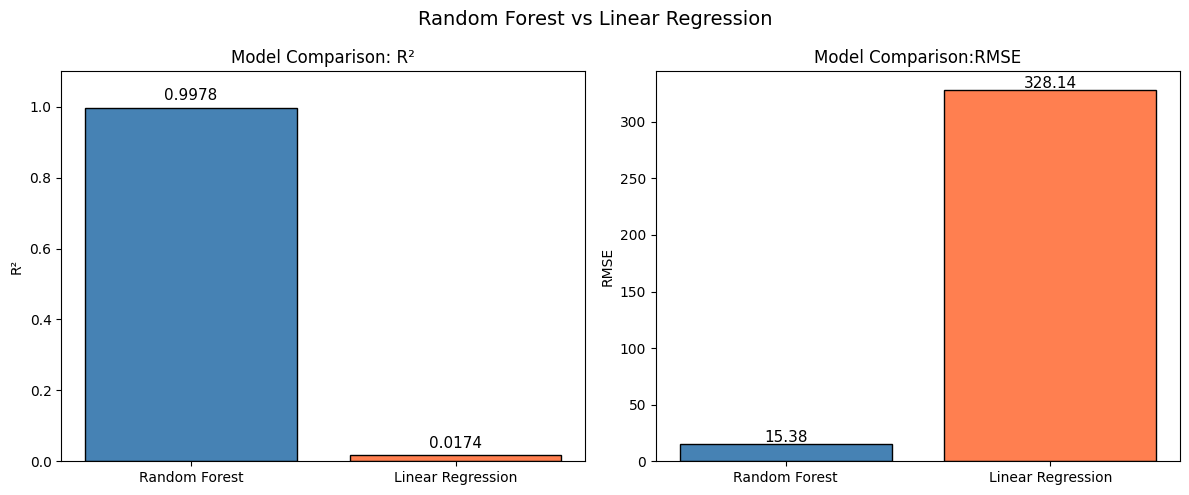

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models    = ['Random Forest', 'Linear Regression']
r2_scores = [r2_rf, r2_lr]
rmse_scores = [rmse_rf, rmse_lr]

# R² chart
axes[0].bar(models, r2_scores,
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Model Comparison: R²', fontsize=12)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.02, f'{v:.4f}',
                 ha='center', fontsize=11)

# RMSE chart
axes[1].bar(models, rmse_scores,
            color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Model Comparison:RMSE', fontsize=12)
axes[1].set_ylabel('RMSE')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 2, f'{v:.2f}',
                 ha='center', fontsize=11)

plt.suptitle('Random Forest vs Linear Regression', fontsize=14)
plt.tight_layout()
plt.show()

### Model Comparison

The bar charts below compare R² and RMSE for both models,
showing the significant performance gap between Random Forest
and Linear Regression.

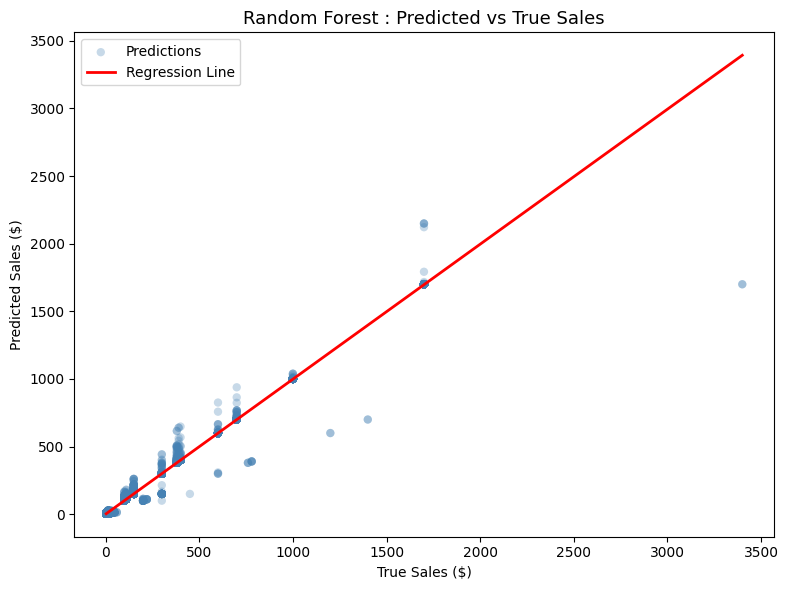

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3,
            color='steelblue', edgecolors='none',
            label='Predictions')
m, b = np.polyfit(y_test, y_pred_rf, 1)
x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, m * x_line + b,
         color='red', linewidth=2,
         label='Regression Line')
plt.title('Random Forest : Predicted vs True Sales', fontsize=13)
plt.xlabel('True Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

## FEATURE IMPORTANCE ANALYSIS

### RESEARCH QUESTION 8:

Which features are most important in predicting sales?

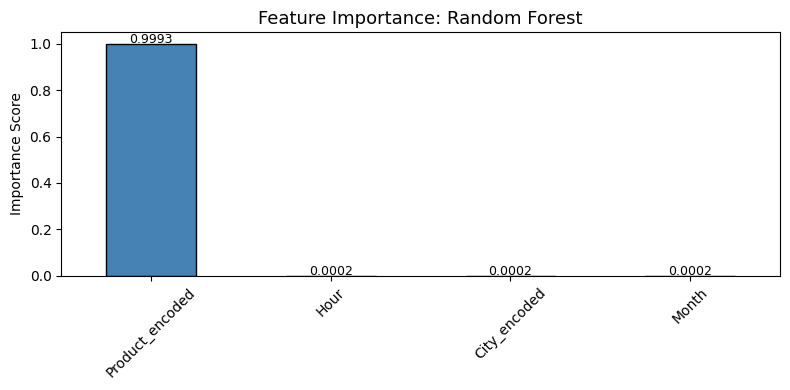


Feature Importance Scores:
Feature                 Score   Percentage
------------------------------------------
  Product_encoded      0.9993        99.9%
  Hour                 0.0002         0.0%
  City_encoded         0.0002         0.0%
  Month                0.0002         0.0%


In [38]:
importance = pd.Series(rf.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance: Random Forest', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
for i, v in enumerate(importance.values):
    plt.text(i, v + 0.005, f'{v:.4f}',
             ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nFeature Importance Scores:")
print(f"{'Feature':<20} {'Score':>8} {'Percentage':>12}")
print("-" * 42)
for feat, score in importance.items():
    print(f"  {feat:<18} {score:>8.4f} {score*100:>11.1f}%")